In [105]:
import time
import pandas as pd
import json
import numpy as np
from datetime import datetime
from datetime import timezone
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from matplotlib.colors import ListedColormap
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import plotly.graph_objects as go
from plotly.subplots import make_subplots


import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [106]:
from scipy.interpolate import interp1d
# resample target
def resample_cycle(cycle, num_points):
	"""Resamples a gait cycle to have a fixed number of points using interpolation."""
	original_indices = np.linspace(0, 1, len(cycle))  # original indices based on the length of the cycle
	new_indices = np.linspace(0, 1, num_points)  # new indices to match the desired number of points
	interpolation_function = interp1d(original_indices, cycle, kind='linear')  # interpolate the data
	return interpolation_function(new_indices)  # return the resampled cycle

In [107]:
def read_json_from_ros2bag(json_file, print_ = False):
	list_of_length = []
	with open(json_file, 'r') as file:
		json_content = json.load(file)
	if print_:
		print('Read: ',json_file)
	for key, value in json_content.items():
		if print_:
			print(f"{key} range: {len(value)}")
		list_of_length.append(len(value))
	cut_data = {key: value[:min(list_of_length)] for key, value in json_content.items()}
	cut_df = pd.DataFrame(cut_data)
	return cut_df


def read_and_normalize_json_from_ros2bag(json_file, print_=False):
	list_of_length = []
	with open(json_file, 'r') as f:
		data = json.load(f)
	if print_:
		print('Read: ',json_file)
	for key, value in data.items():
		if print_:
			print(f"{key} range: {len(value)}")
		list_of_length.append(len(value))
	# Normalize the data into a DataFrame
	df = pd.json_normalize(data)
	return df

def remove_specific_cycles(data_loader, indices_to_remove):
	"""
	Excludes specific indices from every key in the dataset.
	indices_to_remove: list of integers (e.g., [1, 3, 6])
	"""
	cleaned_data = {}
	
	for key in data_loader.files:
		original_list = list(data_loader[key])
		# Keep only the items whose index is NOT in our 'remove' list
		cleaned_data[key] = [
			cycle for i, cycle in enumerate(original_list) 
			if i not in indices_to_remove
		]
		
	return cleaned_data

def get_cycle_stats(data_source, param_prefix, leg, norm_points=100):
	"""
	Interpolates cycles for a specific leg/parameter and calculates mean/std.
	"""
	key = f'{param_prefix}_{leg}'
	if key not in data_source:
		return None, None, None

	raw_cycles = data_source[key]
	normalized_list = []
	

	for j, cycle in enumerate(raw_cycles):
			
		x_old = np.linspace(0, 100, len(cycle))
		x_new = np.linspace(0, 100, norm_points)
		norm_cycle = np.interp(x_new, x_old, cycle)
		normalized_list.append(norm_cycle)
	
	if not normalized_list:
		return None, None, None

	norm_matrix = np.array(normalized_list)
	mean_vals = np.mean(norm_matrix, axis=0)
	std_vals = np.std(norm_matrix, axis=0)
	x_axis = np.linspace(0, 100, norm_points)

	return x_axis, mean_vals, std_vals

def process_sensor_data(input_df, sensor_key, output_column, window_slide=1, shift=0):
	sensor_val = []
	sensor_ts = []
	sensor_df = []

	for i in range(len(input_df[sensor_key][0])):
		sensor_val.append(input_df[sensor_key][0][i]['val'])
		sensor_ts.append(input_df[sensor_key][0][i]['ts'])

	sensor_df = pd.DataFrame(sensor_val, columns=output_column)
	sensor_df = sensor_df.shift(shift)
	sensor_df = sensor_df.rolling(window=window_slide).mean()
	sensor_df['ts'] = sensor_ts

	return sensor_df

Found 16 CSV file(s). Processing...

--- COPY AND PASTE THESE INTO YOUR CONFIG ---
DESIRED_GAIT_ORDER = ['muddy_ground_gait', 'slippery_ground_gait', 'solid_ground_gait', 'water_surface_gait']
DESIRED_ENV_ORDER = ['muddy_ground', 'slippery_ground', 'solid_ground', 'water_surface']

Plot saved successfully to: gait_vs_environment_COT_grid.png


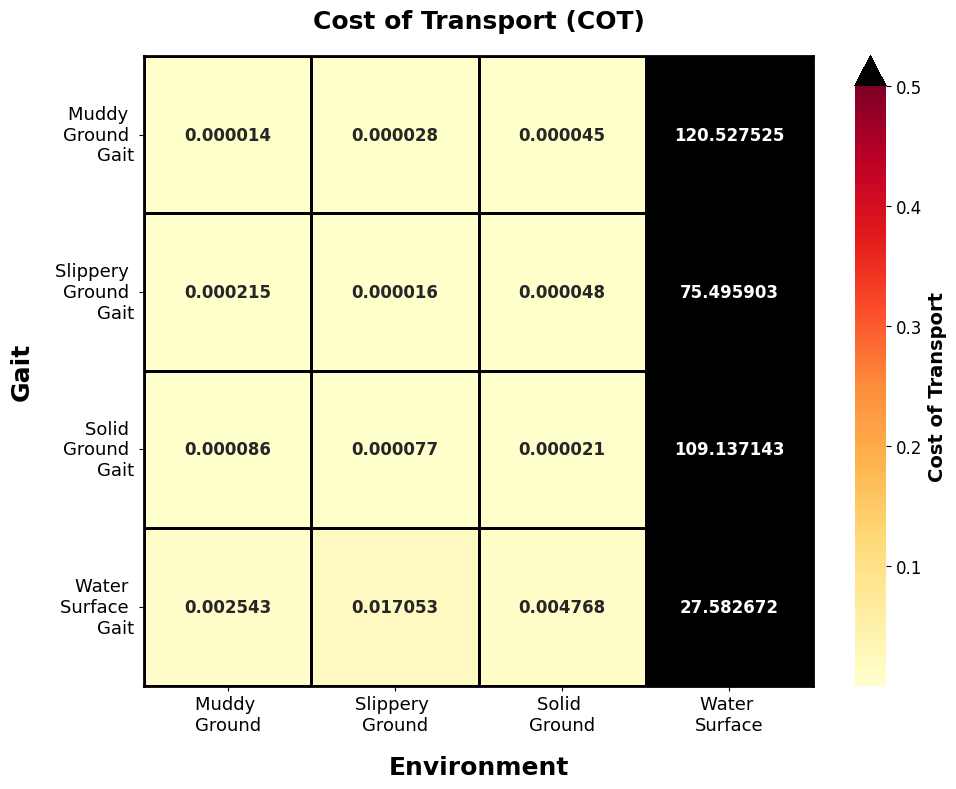

In [108]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import copy # <-- NEW: Needed to modify the colormap safely

# ==========================================
# CONFIGURATION
# ==========================================
CSV_FOLDER = "" 

def load_and_average_csvs(folder_path):
    """Finds CSV files, extracts Gait/Env from filename, and calculates averages."""
    search_pattern = os.path.join(folder_path, "*.csv")
    csv_files = glob.glob(search_pattern)
    
    if not csv_files:
        print(f"No CSV files found in {folder_path}!")
        return None

    print(f"Found {len(csv_files)} CSV file(s). Processing...")
    
    avg_data = []
    
    for file in sorted(csv_files):
        df = pd.read_csv(file)
        
        # Calculate the average of all numeric columns in this file
        numeric_cols = df.select_dtypes(include='number').columns
        avg_row = df[numeric_cols].mean().to_dict()
        
        # 🚨 PARSE THE FILENAME 🚨
        # Filename expected format: "gait_name_on_environment_name.csv"
        filename_clean = os.path.splitext(os.path.basename(file))[0]
        
        if "_on_" in filename_clean:
            # Split the string at "_on_"
            gait_name, env_name = filename_clean.split('_on_', 1)
        else:
            # Fallback if a file doesn't follow the naming convention
            gait_name = filename_clean
            env_name = "Unknown_Environment"
            
        avg_row['Gait'] = gait_name.replace('_', ' \n').title()
        avg_row['Environment'] = env_name.replace('_', ' \n').title()
        avg_row['Episodes_Count'] = len(df)
        
        avg_data.append(avg_row)
        
    return pd.DataFrame(avg_data)

def plot_cot_heatmap(df):
    """Generates a 2D grid (heatmap) for Cost of Transport: Gait vs Environment."""
    
    # 1. Pivot the data into a 2D Matrix (Rows = Gait, Columns = Environment)
    pivot_df = df.pivot_table(
        index='Gait', 
        columns='Environment', 
        values='Cost_of_Transport', 
        aggfunc='mean'
    )
    
    # 2. Set up the plot window
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # ==========================================
    # 🚨 NEW: CUSTOM COLORMAP LOGIC
    # ==========================================
    # Get the base Yellow-Orange-Red colormap
    my_cmap = copy.copy(plt.get_cmap("YlOrRd"))
    # Tell it to color anything above the maximum threshold as solid black
    my_cmap.set_over('black')
    
    # 3. Draw the Heatmap
    sns.heatmap(
        pivot_df, 
        annot=True,          
        fmt=".6f",           
        cmap=my_cmap,        
        vmax=0.5,            
        linewidths=1,        
        linecolor='black',
        annot_kws={"size": 12, "weight": "bold"},  # <-- NEW: Adjust 'size' to make text larger/smaller
        cbar_kws={
            'label': 'Cost of Transport', 
            'extend': 'max'  
        },
        ax=ax
    )
    # ==========================================
    # 🚨 NEW: COLORBAR FONT SIZE LOGIC
    # ==========================================
    # Get the colorbar object attached to the heatmap
    cbar = ax.collections[0].colorbar
    
    # 1. Change the font size of the colorbar NUMBERS (ticks)
    cbar.ax.tick_params(labelsize=12) 
    
    # 2. Change the font size of the colorbar LABEL ("Cost of Transport")
    cbar.set_label('Cost of Transport', size=14, weight='bold')
    
    # ==========================================
    for _, spine in ax.spines.items():
        spine.set_visible(True)     # Make sure the frame is turned on
        spine.set_linewidth(2.0)    # Set the outer frame thickness to 3
        spine.set_color('black')    # Set the outer frame color

    # 4. Formatting labels and titles
    ax.set_title("Cost of Transport (COT)", 
                 fontsize=18, fontweight='bold', pad=20)
    ax.set_xlabel("Environment", fontsize=18, fontweight='bold', labelpad=15)
    ax.set_ylabel("Gait", fontsize=18, fontweight='bold', labelpad=15)
    
    # Rotate the X-axis labels slightly if the environment names are long
    plt.xticks(rotation=0, fontsize=13)
    plt.yticks(rotation=0, fontsize=13)
    
    # Automatically adjust spacing
    plt.tight_layout() 
    
    # Save the plot
    save_path = "gait_vs_environment_COT_grid.png"
    plt.savefig(save_path, dpi=300)
    print(f"Plot saved successfully to: {save_path}")
    
    # Show the plot
    plt.show()

if __name__ == "__main__":
    # 1. Load Data
    df = load_and_average_csvs(CSV_FOLDER)
    
    if df is not None and not df.empty:
        # ==========================================
        # 🚨 ADD THIS TO PRINT THE RAW NAMES
        # ==========================================
        # Reverse the formatting to get the original raw names back
        raw_gaits = [g.replace(' \n', '_').lower() for g in df['Gait'].unique()]
        raw_envs = [e.replace(' \n', '_').lower() for e in df['Environment'].unique()]
        
        print("\n--- COPY AND PASTE THESE INTO YOUR CONFIG ---")
        print(f"DESIRED_GAIT_ORDER = {raw_gaits}")
        print(f"DESIRED_ENV_ORDER = {raw_envs}\n")
        # ==========================================
        
        # 2. Plot the Heatmap Grid
        plot_cot_heatmap(df)

Found 16 CSV file(s). Processing...
Plot saved successfully to: gait_vs_environment_COT_grid.png


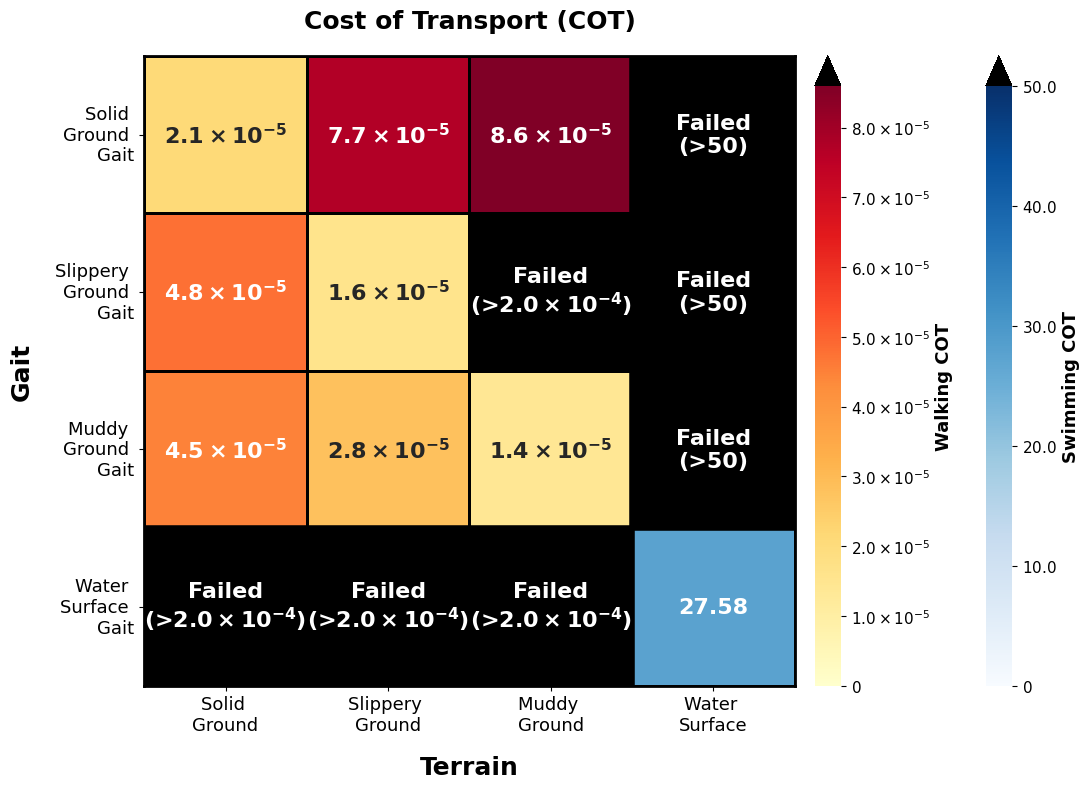

In [124]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import copy
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.ticker import FuncFormatter

# ==========================================
# CONFIGURATION
# ==========================================
CSV_FOLDER = "" 

DESIRED_GAIT_ORDER = ['solid_ground_gait',   
                      'slippery_ground_gait', 
                      'rough_ground_gait', 
                      'muddy_ground_gait',  
                      'soft_ground_gait', 
                      'water_surface_gait']
DESIRED_ENV_ORDER = ['solid_ground', 
                     'slippery_ground', 
                     'rough_ground', 
                     'muddy_ground',  
                     'soft_ground', 
                     'water_surface']

# 🚨 NEW: Define the scales for your two different domains
WALK_VMAX = 0.0002
SWIM_VMAX = 50  # Tune this to match your normal swimming COT range

def load_and_average_csvs(folder_path):
    search_pattern = os.path.join(folder_path, "*.csv")
    csv_files = glob.glob(search_pattern)
    
    if not csv_files:
        print(f"No CSV files found in {folder_path}!")
        return None

    print(f"Found {len(csv_files)} CSV file(s). Processing...")
    
    avg_data = []
    
    for file in sorted(csv_files):
        df = pd.read_csv(file)
        
        numeric_cols = df.select_dtypes(include='number').columns
        avg_row = df[numeric_cols].mean().to_dict()
        
        filename_clean = os.path.splitext(os.path.basename(file))[0]
        
        if "_on_" in filename_clean:
            gait_name, env_name = filename_clean.split('_on_', 1)
        else:
            gait_name = filename_clean
            env_name = "Unknown_Environment"
            
        avg_row['Gait'] = gait_name.replace('_', ' \n').title()
        avg_row['Environment'] = env_name.replace('_', ' \n').title()
        avg_row['Episodes_Count'] = len(df)
        
        avg_data.append(avg_row)
        
    return pd.DataFrame(avg_data)


def plot_cot_heatmap(df):
    """Generates a 2D grid (heatmap) with dual color scales for walking vs swimming."""
    
    # 1. Pivot the data into a 2D Matrix
    pivot_df = df.pivot_table(
        index='Gait', 
        columns='Environment', 
        values='Cost_of_Transport', 
        aggfunc='mean'
    )
    
    # ==========================================
    # REORDER THE DATAFRAME
    # ==========================================
    gait_order_formatted = [g.replace('_', ' \n').title() for g in DESIRED_GAIT_ORDER]
    env_order_formatted = [e.replace('_', ' \n').title() for e in DESIRED_ENV_ORDER]
    
    existing_gaits = [g for g in gait_order_formatted if g in pivot_df.index]
    existing_envs = [e for e in env_order_formatted if e in pivot_df.columns]
    
    pivot_df = pivot_df.reindex(index=existing_gaits, columns=existing_envs)
    
    # ==========================================
    # CUSTOM ANNOTATIONS MATRIX (Scientific Notation)
    # ==========================================
    annot_matrix = pivot_df.copy().astype(object)
    
    water_col = 'Water \nSurface'
    water_row = 'Water \nSurface \nGait'
    
    # Helper function to beautifully format small numbers in Matplotlib MathText
    def format_sci(v):
        if v == 0: return "$\\mathbf{0}$"
        
        # Convert to scientific string (e.g., '5.1e-05')
        sci_str = f"{v:.1e}" 
        coeff, exp = sci_str.split('e')
        
        # Assemble Bold MathText: $\mathbf{5.1 \times 10^{-5}}$
        # String concatenation is used here to avoid f-string bracket confusion!
        return "$\\mathbf{" + f"{coeff} \\times 10^{{{int(exp)}}}" + "}$"

    for row in pivot_df.index:
        for col in pivot_df.columns:
            val = pivot_df.loc[row, col]
            
            # Handle empty cells
            if pd.isna(val):
                annot_matrix.loc[row, col] = ""
                continue
                
            # 🚨 Check if the cell belongs to the Swimming/Water domain
            if col == water_col:
                # --- SWIMMING FORMATTING ---
                if val > SWIM_VMAX:
                    annot_matrix.loc[row, col] = f"Failed\n(>{(SWIM_VMAX)})"
                else:
                    # If swimming COT happens to be tiny (< 0.01), make it scientific too!
                    if 0 < val < 0.01:
                        annot_matrix.loc[row, col] = format_sci(val)
                    else:
                        annot_matrix.loc[row, col] = f"{val:.2f}" 
            
            else:
                # --- WALKING FORMATTING ---
                if val > WALK_VMAX:
                    annot_matrix.loc[row, col] = f"Failed\n(>{format_sci(WALK_VMAX)})"
                else:
                    # Apply scientific formatting to all walking numbers
                    annot_matrix.loc[row, col] = format_sci(val)
                
    custom_annotations = annot_matrix.values
    
    # ==========================================
    # 🚨 DUAL SCALE MASKING LOGIC (ROW & COLUMN)
    # ==========================================
    water_col = 'Water \nSurface'
    water_row = 'Water \nSurface \nGait'
    
    # Create True/False masks (True means "Hide this cell")
    walk_mask = pd.DataFrame(True, index=pivot_df.index, columns=pivot_df.columns)
    swim_mask = pd.DataFrame(True, index=pivot_df.index, columns=pivot_df.columns)
    
    # Loop through all cells and assign them to the correct scale
    for row in pivot_df.index:
        for col in pivot_df.columns:
            # If it is the Water Gait OR the Water Terrain, use the Swim (Blue) scale
            if col == water_col:  #  row == water_row or 
                swim_mask.loc[row, col] = False  # Unmask for Swim
            # Otherwise, use the Walking (Red) scale
            else:
                walk_mask.loc[row, col] = False  # Unmask for Walk

    # ==========================================
    # 2. SET UP PLOT & COLORBAR AXES
    # ==========================================
    fig, ax = plt.subplots(figsize=(11, 8)) 
    
    divider = make_axes_locatable(ax)
    cbar_walk_ax = divider.append_axes("right", size="4%", pad=0.2)
    cbar_swim_ax = divider.append_axes("right", size="4%", pad=1.45)

    cmap_walk = copy.copy(plt.get_cmap("YlOrRd"))
    cmap_walk.set_over('black')
    
    cmap_swim = copy.copy(plt.get_cmap("Blues"))
    cmap_swim.set_over('black')

    # ==========================================
    # 3. DRAW THE HEATMAP LAYERS
    # ==========================================
    # Layer 1: Plot Walking Terrains & Gaits
    sns.heatmap(
        pivot_df, 
        mask=walk_mask, 
        annot=custom_annotations, 
        fmt="", 
        cmap=cmap_walk,
        vmin=0.0,             # 🚨 Force minimum to 0 to fix auto-scaling bugs
        vmax=8.6*10**-5,            
        linewidths=1,        
        linecolor='black',
        annot_kws={"size": 16, "weight": "bold"}, 
        cbar_ax=cbar_walk_ax,
        cbar_kws={'label': 'Walking COT', 'extend': 'max'},
        ax=ax
    )
    
    # Layer 2: Plot Swimming Terrain & Gaits (Overlays perfectly)
    sns.heatmap(
        pivot_df, 
        mask=swim_mask, 
        annot=custom_annotations, 
        fmt="", 
        cmap=cmap_swim,
        vmin=0.0,             # 🚨 Force minimum to 0 to fix auto-scaling bugs
        vmax=SWIM_VMAX,            
        linewidths=1,        
        linecolor='black',
        annot_kws={"size": 16, "weight": "bold"}, 
        cbar_ax=cbar_swim_ax,
        cbar_kws={'label': 'Swimming COT', 'extend': 'max'},
        ax=ax
    )
    
    # Draw thicker black lines to visually separate the Water row/column
    if water_col in pivot_df.columns:
        water_c_idx = list(pivot_df.columns).index(water_col)
        ax.axvline(x=water_c_idx, color='black', linewidth=4)
    if water_row in pivot_df.index:
        water_r_idx = list(pivot_df.index).index(water_row)
        ax.axhline(y=water_r_idx, color='black', linewidth=4)

    # ==========================================
    # 4. FORMATTING LABELS AND SPINES
    # ==========================================
    # Create formatters to match the bold scientific MathText inside the cells
    def cb_format_walk(v, pos):
        if v == 0: return "${0}$"
        sci_str = f"{v:.1e}"
        coeff, exp = sci_str.split('e')
        return "${" + f"{coeff}\\times10^{{{int(exp)}}}" + "}$"

    def cb_format_swim(v, pos):
        if v == 0: return "${0}$"
        if v < 0.01:
            sci_str = f"{v:.1e}"
            coeff, exp = sci_str.split('e')
            return "${" + f"{coeff}\\times10^{{{int(exp)}}}" + "}$"
        return f"${{{v:.1f}}}$" # Standard bold decimal for large swim values

    # Apply the formatter and styling to Walking Colorbar
    cbar_walk_ax.yaxis.set_major_formatter(FuncFormatter(cb_format_walk))
    cbar_walk_ax.tick_params(labelsize=11)
    cbar_walk_ax.set_ylabel('Walking COT', size=13, weight='bold')
    
    # Apply the formatter and styling to Swimming Colorbar
    if water_col in pivot_df.columns:
        cbar_swim_ax.yaxis.set_major_formatter(FuncFormatter(cb_format_swim))
        cbar_swim_ax.tick_params(labelsize=11)
        cbar_swim_ax.set_ylabel('Swimming COT', size=13, weight='bold')

    # Spines
    for _, spine in ax.spines.items():
        spine.set_visible(True)     
        spine.set_linewidth(2.0)    
        spine.set_color('black')

    ax.set_title("Cost of Transport (COT)", fontsize=18, fontweight='bold', pad=20)
    ax.set_xlabel("Terrain", fontsize=18, fontweight='bold', labelpad=15)
    ax.set_ylabel("Gait", fontsize=18, fontweight='bold', labelpad=15)
    
    ax.tick_params(axis='x', rotation=0, labelsize=13)
    ax.tick_params(axis='y', rotation=0, labelsize=13)
    
    plt.tight_layout() 
    
    save_path = "gait_vs_environment_COT_grid.png"
    plt.savefig(save_path, dpi=300)
    print(f"Plot saved successfully to: {save_path}")
    
    plt.show()

if __name__ == "__main__":
    df = load_and_average_csvs(CSV_FOLDER)
    if df is not None and not df.empty:
        plot_cot_heatmap(df)

# Instability plot

Found 16 CSV file(s). Processing...

--- Processed Data Summary ---
                Gait     Environment  Stability_Index
   Muddy Ground Gait    Muddy Ground         0.677642
   Muddy Ground Gait Slippery Ground         0.028688
   Muddy Ground Gait    Solid Ground         0.632187
   Muddy Ground Gait   Water Surface         0.025044
Slippery Ground Gait    Muddy Ground         0.191323
Slippery Ground Gait Slippery Ground         0.017883
Slippery Ground Gait    Solid Ground         0.241753
Slippery Ground Gait   Water Surface         0.011870
   Solid Ground Gait    Muddy Ground         0.017909
   Solid Ground Gait Slippery Ground         0.011067
   Solid Ground Gait    Solid Ground         0.114330
   Solid Ground Gait   Water Surface         0.010082
  Water Surface Gait    Muddy Ground         0.066209
  Water Surface Gait Slippery Ground         0.096272
  Water Surface Gait    Solid Ground         0.129165
  Water Surface Gait   Water Surface         0.010480
Plot saved suc

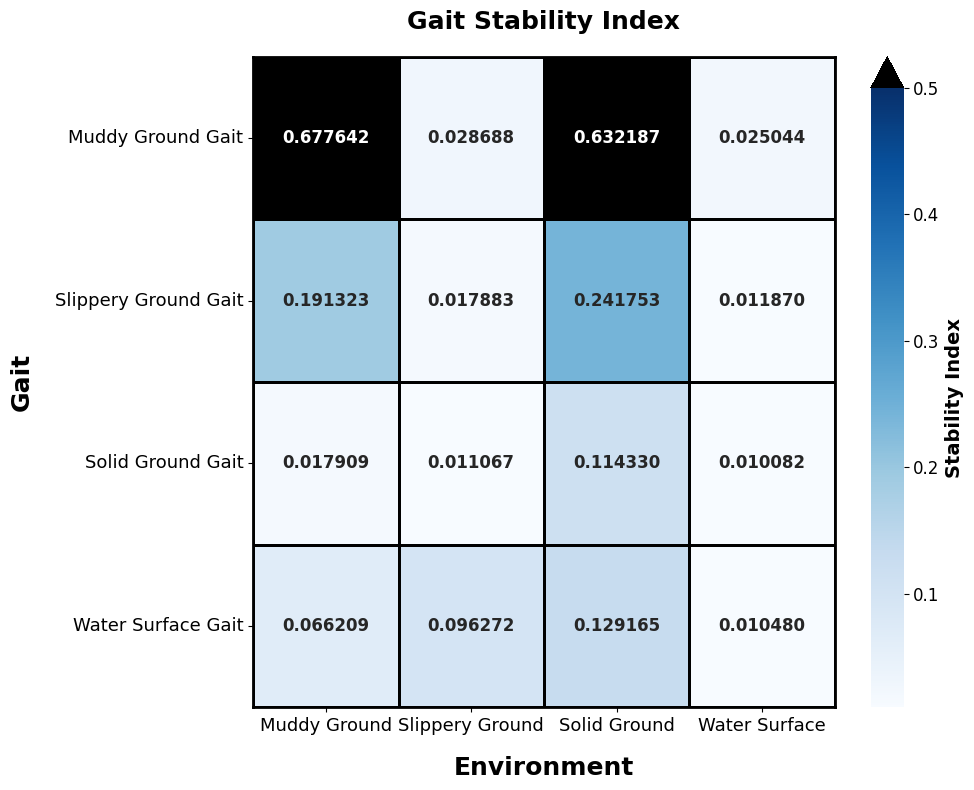

In [123]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import copy

# ==========================================
# CONFIGURATION
# ==========================================
CSV_FOLDER = ""

def load_and_average_csvs(folder_path):
    """Finds CSV files, extracts Gait/Env from filename, and calculates averages."""
    search_pattern = os.path.join(folder_path, "*.csv")
    csv_files = glob.glob(search_pattern)

    if not csv_files:
        print(f"No CSV files found in {folder_path}!")
        return None

    print(f"Found {len(csv_files)} CSV file(s). Processing...")

    avg_data = []

    for file in sorted(csv_files):
        df = pd.read_csv(file)

        # Calculate the average of all numeric columns in this file
        numeric_cols = df.select_dtypes(include='number').columns
        avg_row = df[numeric_cols].mean().to_dict()

        # Filename expected format: "gait_name_on_environment_name.csv"
        filename_clean = os.path.splitext(os.path.basename(file))[0]

        if "_on_" in filename_clean:
            gait_name, env_name = filename_clean.split('_on_', 1)
        else:
            gait_name = filename_clean
            env_name = "Unknown_Environment"

        avg_row['Gait'] = gait_name.replace('_', ' ').title()
        avg_row['Environment'] = env_name.replace('_', ' ').title()
        avg_row['Episodes_Count'] = len(df)

        avg_data.append(avg_row)

    return pd.DataFrame(avg_data)


def plot_instability_heatmap(df):
    """Generates a 2D grid (heatmap) for Stability Index: Gait vs Environment."""

    # 1. Pivot the data into a 2D Matrix (Rows = Gait, Columns = Environment)
    pivot_df = df.pivot_table(
        index='Gait',
        columns='Environment',
        values='Stability_Index',
        aggfunc='mean'
    )

    # 2. Set up the plot window
    fig, ax = plt.subplots(figsize=(10, 8))

    # Color anything above vmax as solid black
    my_cmap = copy.copy(plt.get_cmap("Blues"))
    my_cmap.set_over('black')

    # 3. Draw the heatmap
    sns.heatmap(
        pivot_df,
        annot=True,
        fmt=".6f",
        cmap=my_cmap,
        vmax=0.5,
        linewidths=1,
        linecolor='black',
        annot_kws={"size": 12, "weight": "bold"},
        cbar_kws={
            'label': 'Stability Index',
            'extend': 'max'
        },
        ax=ax
    )

    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=12)
    cbar.set_label('Stability Index', size=14, weight='bold')

    for _, spine in ax.spines.items():
        spine.set_visible(True)
        spine.set_linewidth(2.0)
        spine.set_color('black')

    # 4. Formatting labels and titles
    ax.set_title("Gait Stability Index", fontsize=18, fontweight='bold', pad=20)
    ax.set_xlabel("Environment", fontsize=18, fontweight='bold', labelpad=15)
    ax.set_ylabel("Gait", fontsize=18, fontweight='bold', labelpad=15)

    plt.xticks(rotation=0, fontsize=13)
    plt.yticks(rotation=0, fontsize=13)
    plt.tight_layout()

    save_path = "gait_vs_environment_stability_grid.png"
    plt.savefig(save_path, dpi=300)
    print(f"Plot saved successfully to: {save_path}")

    plt.show()


if __name__ == "__main__":
    df = load_and_average_csvs(CSV_FOLDER)

    if df is not None and not df.empty:
        print("\n--- Processed Data Summary ---")
        print(df[['Gait', 'Environment', 'Stability_Index']].to_string(index=False))

        plot_instability_heatmap(df)
